# Import

In [1]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import calendar

# Domain & Period

In [2]:
iyear=1940
fyear=2025
dom='HMA'

In [3]:
#load eastward (u) and northward (v) of IVT
uivt = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/uivt_monthly_era5_1940-2025_NH_025x025.nc')
vivt = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/vivt_monthly_era5_1940-2025_NH_025x025.nc')

#load tcwv
tcwv = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/tcwv_monthly_era5_1940-2025_NH_025x025.nc')
tcwv = tcwv.sel(valid_time=slice(f"{iyear}-01-01", f"{fyear}-12-31"))

In [4]:
#focus on High Mountain Asia (HMA)
uivt_MA = field_dom(uivt,dom)
vivt_MA = field_dom(vivt,dom)
tcwv_MA = field_dom(tcwv,dom)

# Annual Mean

In [5]:
tcwv_mean = tcwv_MA['tcwv'].mean(dim='valid_time')

In [6]:
u_mean = uivt_MA['viwve'].mean(dim='valid_time')

In [7]:
v_mean = vivt_MA['viwvn'].mean(dim='valid_time')

<xarray.DataArray 'tcwv' ()> Size: 4B
array(45.56432, dtype=float32)
Coordinates:
    number   int64 8B ...


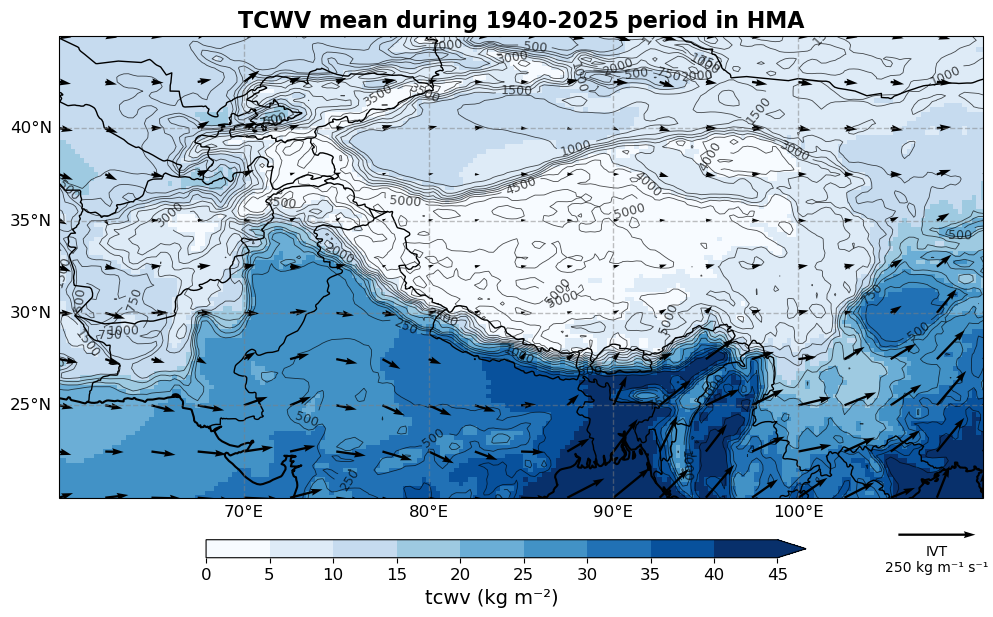

In [8]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,6))

#tcwv color definition
#vmax=60
vmax=tcwv_mean.max()
print(vmax)
levels = np.arange(0, vmax, 5)
cmap = plt.get_cmap("Blues", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, cmap.N)
pcm = ax.pcolormesh(
    tcwv_mean['longitude'], tcwv_mean['latitude'], tcwv_mean,
    cmap=cmap, norm=norm,transform=ccrs.PlateCarree())

#Map limitations
ax.set_extent([
    float(tcwv_mean.longitude.min()),
    float(tcwv_mean.longitude.max()),
    float(tcwv_mean.latitude.min()),
    float(tcwv_mean.latitude.max())
], crs=ccrs.PlateCarree())

#tcwv Vectors
step = 6
u_plot = u_mean[::step, ::step]
v_plot = v_mean[::step, ::step]
q = ax.quiver(u_plot['longitude'],u_plot['latitude'],u_plot,v_plot,transform=ccrs.PlateCarree(),scale=3000,width=0.0025,headwidth=3
             ,rasterized=True)

#Borders
ax.coastlines(linewidth=1.5)
ax.add_feature(cfeature.BORDERS, linewidth=1)

#Courbes de niveau
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="k",linewidths=0.6,alpha=0.7,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

#Grid of lat & lon
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

#Legends
cbar_ax = fig.add_axes([0.25, 0.01, 0.5, 0.03])
cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', extend='max')
cbar.set_label("tcwv (kg m⁻²)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.quiverkey(q,0.95, -0.08,    250,"IVT\n250 kg m⁻¹ s⁻¹",labelpos='S',coordinates='axes')
ax.set_title(f"TCWV mean during {iyear}-{fyear} period in {dom}", fontsize=16, weight='bold')

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'tcwv_mean_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Monthly Climatology of tcwv

In [9]:
#Group by month + mean
monthly_clim = tcwv_MA.groupby('valid_time.month').mean('valid_time')['tcwv']
u_monthly_clim = uivt_MA.groupby('valid_time.month').mean('valid_time')['viwve']
v_monthly_clim = vivt_MA.groupby('valid_time.month').mean('valid_time')['viwvn']

69.52281951904297


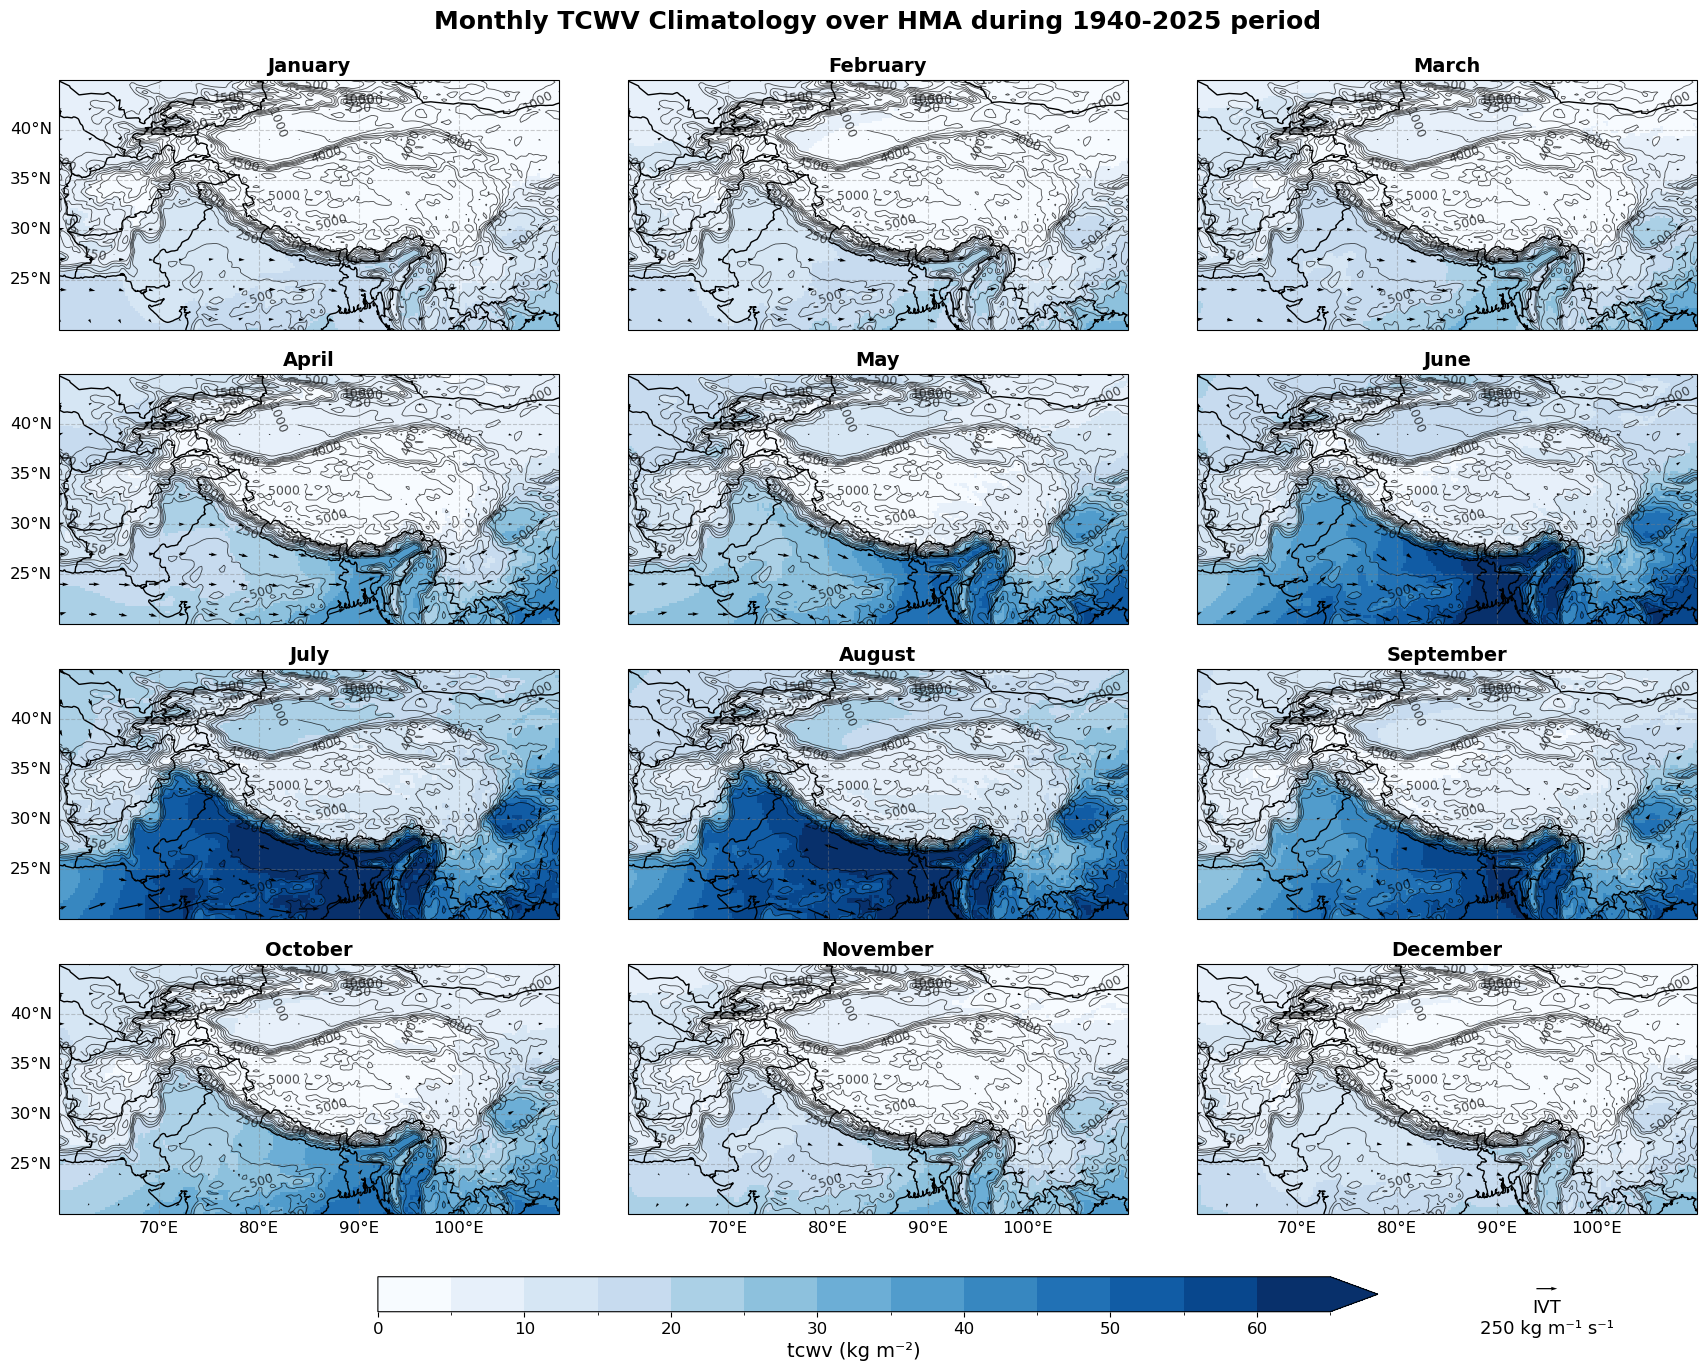

In [10]:
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']

#vmax=60
vmax = float(monthly_clim.max())
print(vmax)
levels = np.arange(0, vmax, 5)
cmap = plt.get_cmap("Blues")
norm = mcolors.BoundaryNorm(levels, cmap.N)

fig, axes = plt.subplots(4, 3,figsize=(20, 14),subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    data_month = monthly_clim.sel(month=i+1)
    im = ax.pcolormesh(data_month.longitude,data_month.latitude,data_month,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    #Map limitations
    ax.set_extent([
        float(tcwv_mean.longitude.min()),
        float(tcwv_mean.longitude.max()),
        float(tcwv_mean.latitude.min()),
        float(tcwv_mean.latitude.max())
    ], crs=ccrs.PlateCarree())

    #IVT Vectors
    step = 8
    u_plot = u_monthly_clim.sel(month=i+1)[::step, ::step]
    v_plot = v_monthly_clim.sel(month=i+1)[::step, ::step]
    q = ax.quiver(u_plot['longitude'],u_plot['latitude'],u_plot,v_plot,transform=ccrs.PlateCarree(),scale=6000,width=0.0025,headwidth=3
             ,rasterized=True)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                    colors="k",linewidths=0.6,alpha=0.7,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(calendar.month_name[i+1],fontsize=14,weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 3 == 0)
    gl.bottom_labels = (i >= 9)
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tcwv (kg m⁻²)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.quiverkey(q,0.70, -0.3,250,"IVT\n250 kg m⁻¹ s⁻¹",labelpos='S',coordinates='axes', fontproperties={'size': 13})

fig.subplots_adjust(left=0.08,right=0.92,top=0.93,bottom=0.12,wspace=0.05,hspace=0.18)
plt.suptitle(f"Monthly TCWV Climatology over {dom} during {iyear}-{fyear} period",fontsize=18,weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'monthly_tcwv_clim_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Seasonal Climatology of tcwv

In [11]:
seasons = ["DJFM", "AM", "JJAS", "ON"]
start_year = iyear
end_year = fyear
clim_dict = {}

u_clim_dict = {}
v_clim_dict = {}

#Rename time dimension for 'clim' function
tcwv_MA = tcwv_MA.rename({'valid_time': 'time'})
uivt_MA = uivt_MA.rename({'valid_time': 'time'})
vivt_MA = vivt_MA.rename({'valid_time': 'time'})

#Climatology for each season
for season in seasons:
    clim_season = clim(tcwv_MA, season=season, imon=1, iyr=start_year, fmon=12, fyr=end_year)
    clim_dict[season] = clim_season
    
    u_clim_season = clim(uivt_MA, season=season, imon=1, iyr=start_year, fmon=12, fyr=end_year)
    u_clim_dict[season] = u_clim_season
    
    v_clim_season = clim(vivt_MA, season=season, imon=1, iyr=start_year, fmon=12, fyr=end_year)
    v_clim_dict[season] = v_clim_season

66.13700103759766


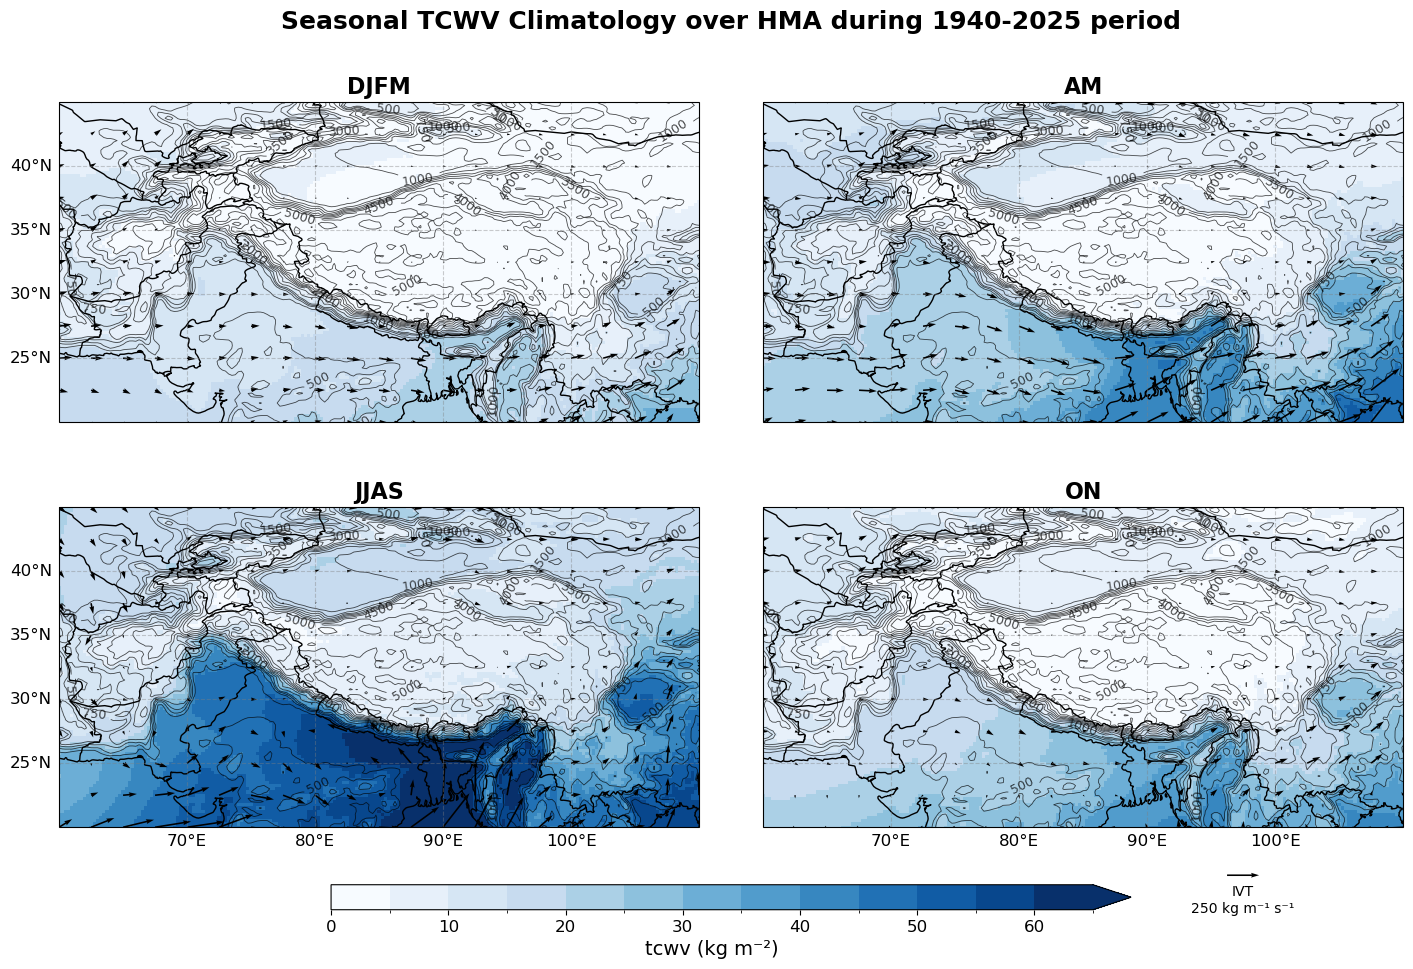

In [12]:
seasons = ["DJFM", "AM", "JJAS", "ON"]
vmin = 0
vmax = max(ds["tcwv"].max().item() for ds in clim_dict.values())
print(vmax)
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']

levels = np.arange(vmin, vmax, 5)
cmap = plt.get_cmap("Blues")
norm = mcolors.BoundaryNorm(levels, cmap.N)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = clim_dict[season]['tcwv']

    im = ax.pcolormesh(data_season.longitude,data_season.latitude,data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,shading="auto")

    #Map limitations
    ax.set_extent([
        float(tcwv_mean.longitude.min()),
        float(tcwv_mean.longitude.max()),
        float(tcwv_mean.latitude.min()),
        float(tcwv_mean.latitude.max())
    ], crs=ccrs.PlateCarree())

    #IVT Vectors
    step = 6
    u_plot = u_clim_dict[season]["viwve"].isel(latitude=slice(None, None, step),longitude=slice(None, None, step))
    v_plot = v_clim_dict[season]["viwvn"].isel(latitude=slice(None, None, step),longitude=slice(None, None, step))
    q = ax.quiver(u_plot.longitude,u_plot.latitude,u_plot,v_plot,transform=ccrs.PlateCarree(),scale=5000,width=0.0025,headwidth=3
             ,rasterized=True)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="k",linewidths=0.6,alpha=0.7,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='max')
cbar.set_label("tcwv (kg m⁻²)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.quiverkey(q,0.75, -0.15, 250,"IVT\n250 kg m⁻¹ s⁻¹",labelpos='S',coordinates='axes')

fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.12, wspace=0.1, hspace=0)
plt.suptitle(f"Seasonal TCWV Climatology over {dom} during {iyear}-{fyear} period", fontsize=18, weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'seasonal_tcwv_clim_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Annual Trend of tcwv

In [19]:
tcwv_annual,_ = seasonal_selection(tcwv_MA['tcwv'], 'JJA', iyear, fyear)
par = trend_vect(tcwv_annual.time,tcwv_annual,dim='time')
trend = par[0];p = par[3]

uivt_annual,_ = seasonal_selection(uivt_MA['viwve'], 'JJA', iyear, fyear)
u_par = trend_vect(uivt_annual.time,uivt_annual,dim='time')
u_trend = u_par[0];u_p = u_par[3]

vivt_annual,_ = seasonal_selection(vivt_MA['viwvn'], 'JJA', iyear, fyear)
v_par = trend_vect(vivt_annual.time,vivt_annual,dim='time')
v_trend = v_par[0];v_p = v_par[3]

0.16


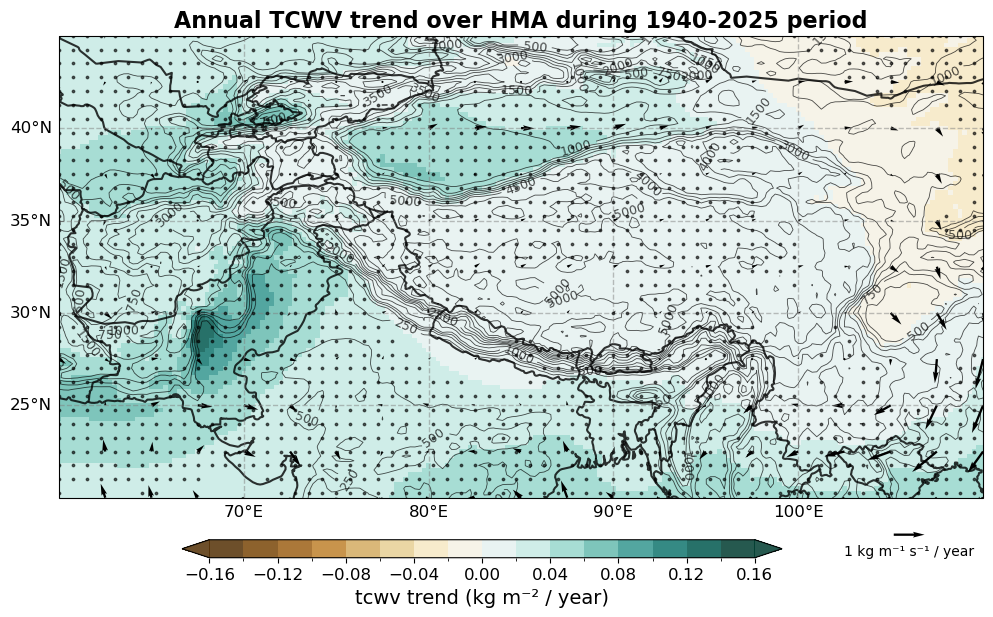

In [20]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12,6))

step = 0.02
vmax = 0.16
#vmax = round(float(np.abs(trend.max().values)), 2)
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, cmap.N)

pcm = ax.pcolormesh(trend['longitude'],trend['latitude'],trend,cmap=cmap,norm=norm,transform=ccrs.PlateCarree(), alpha=0.85)

#Map limitations
ax.set_extent([
    float(tcwv_mean.longitude.min()),
    float(tcwv_mean.longitude.max()),
    float(tcwv_mean.latitude.min()),
    float(tcwv_mean.latitude.max())
], crs=ccrs.PlateCarree())

sig = p < 0.05   # significativity threshold
step = 3  # for stepping the points on the map that appears. 1 point out of 2 on every direction.
#ax.contourf(trend['longitude'],trend['latitude'],sig,levels=[0.5, 1],hatches=['///'],colors='none',transform=ccrs.PlateCarree())
lon_sig, lat_sig = trend['longitude'].values, trend['latitude'].values
lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
          color='black', s=3, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.6)

#IVT Vectors
step = 10
u_plot = u_trend[::step, ::step]
v_plot = v_trend[::step, ::step]
q = ax.quiver(u_plot['longitude'],u_plot['latitude'],u_plot,v_plot,transform=ccrs.PlateCarree(),scale=30,width=0.0025,headwidth=2.5
             ,rasterized=True)

ax.coastlines(linewidth=1.5, alpha = 0.8)
ax.add_feature(cfeature.BORDERS, linewidth=1.5, alpha = 0.8)

elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="k",linewidths=0.6,alpha=0.7,transform=ccrs.PlateCarree())
ax.clabel(SH, inline=True, fontsize=9, fmt="%d")

gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.23, 0.01, 0.5, 0.03])
cbar = fig.colorbar(pcm, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label("tcwv trend (kg m⁻² / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.quiverkey(q,0.92, -0.08, 1,"1 kg m⁻¹ s⁻¹ / year",labelpos='S',coordinates='axes')

ax.set_title(f"Annual TCWV trend over {dom} during {iyear}-{fyear} period", fontsize=16, weight='bold')

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'tcwv_trend_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Monthly Trends of tcwv

In [21]:
seasons = [1,2,3,4,5,6,7,8,9,10,11,12]
start_year = iyear
end_year = fyear
trend_dict = {}
p_dict = {}

u_trend_dict = {}
u_p_dict = {}
v_trend_dict = {}
v_p_dict = {}

#Climatology for each season
for season in seasons:
    tcwv_season,_ = monthly_selection(tcwv_MA['tcwv'], season, start_year, end_year)
    par = trend_vect(tcwv_season.time.dt.year,tcwv_season,dim='time')
    trend_season = par[0];p_season = par[3]
    trend_dict[season] = trend_season
    p_dict[season] = p_season

    uivt_season,_ = monthly_selection(uivt_MA['viwve'], season, start_year, end_year)
    u_par = trend_vect(uivt_season.time.dt.year,uivt_season,dim='time')
    u_trend_season = u_par[0];u_p_season = u_par[3]
    u_trend_dict[season] = u_trend_season
    u_p_dict[season] = u_p_season

    vivt_season,_ = monthly_selection(vivt_MA['viwvn'], season, start_year, end_year)
    v_par = trend_vect(vivt_season.time.dt.year,vivt_season,dim='time')
    v_trend_season = v_par[0];v_p_season = v_par[3]
    v_trend_dict[season] = v_trend_season
    v_p_dict[season] = v_p_season

0.16


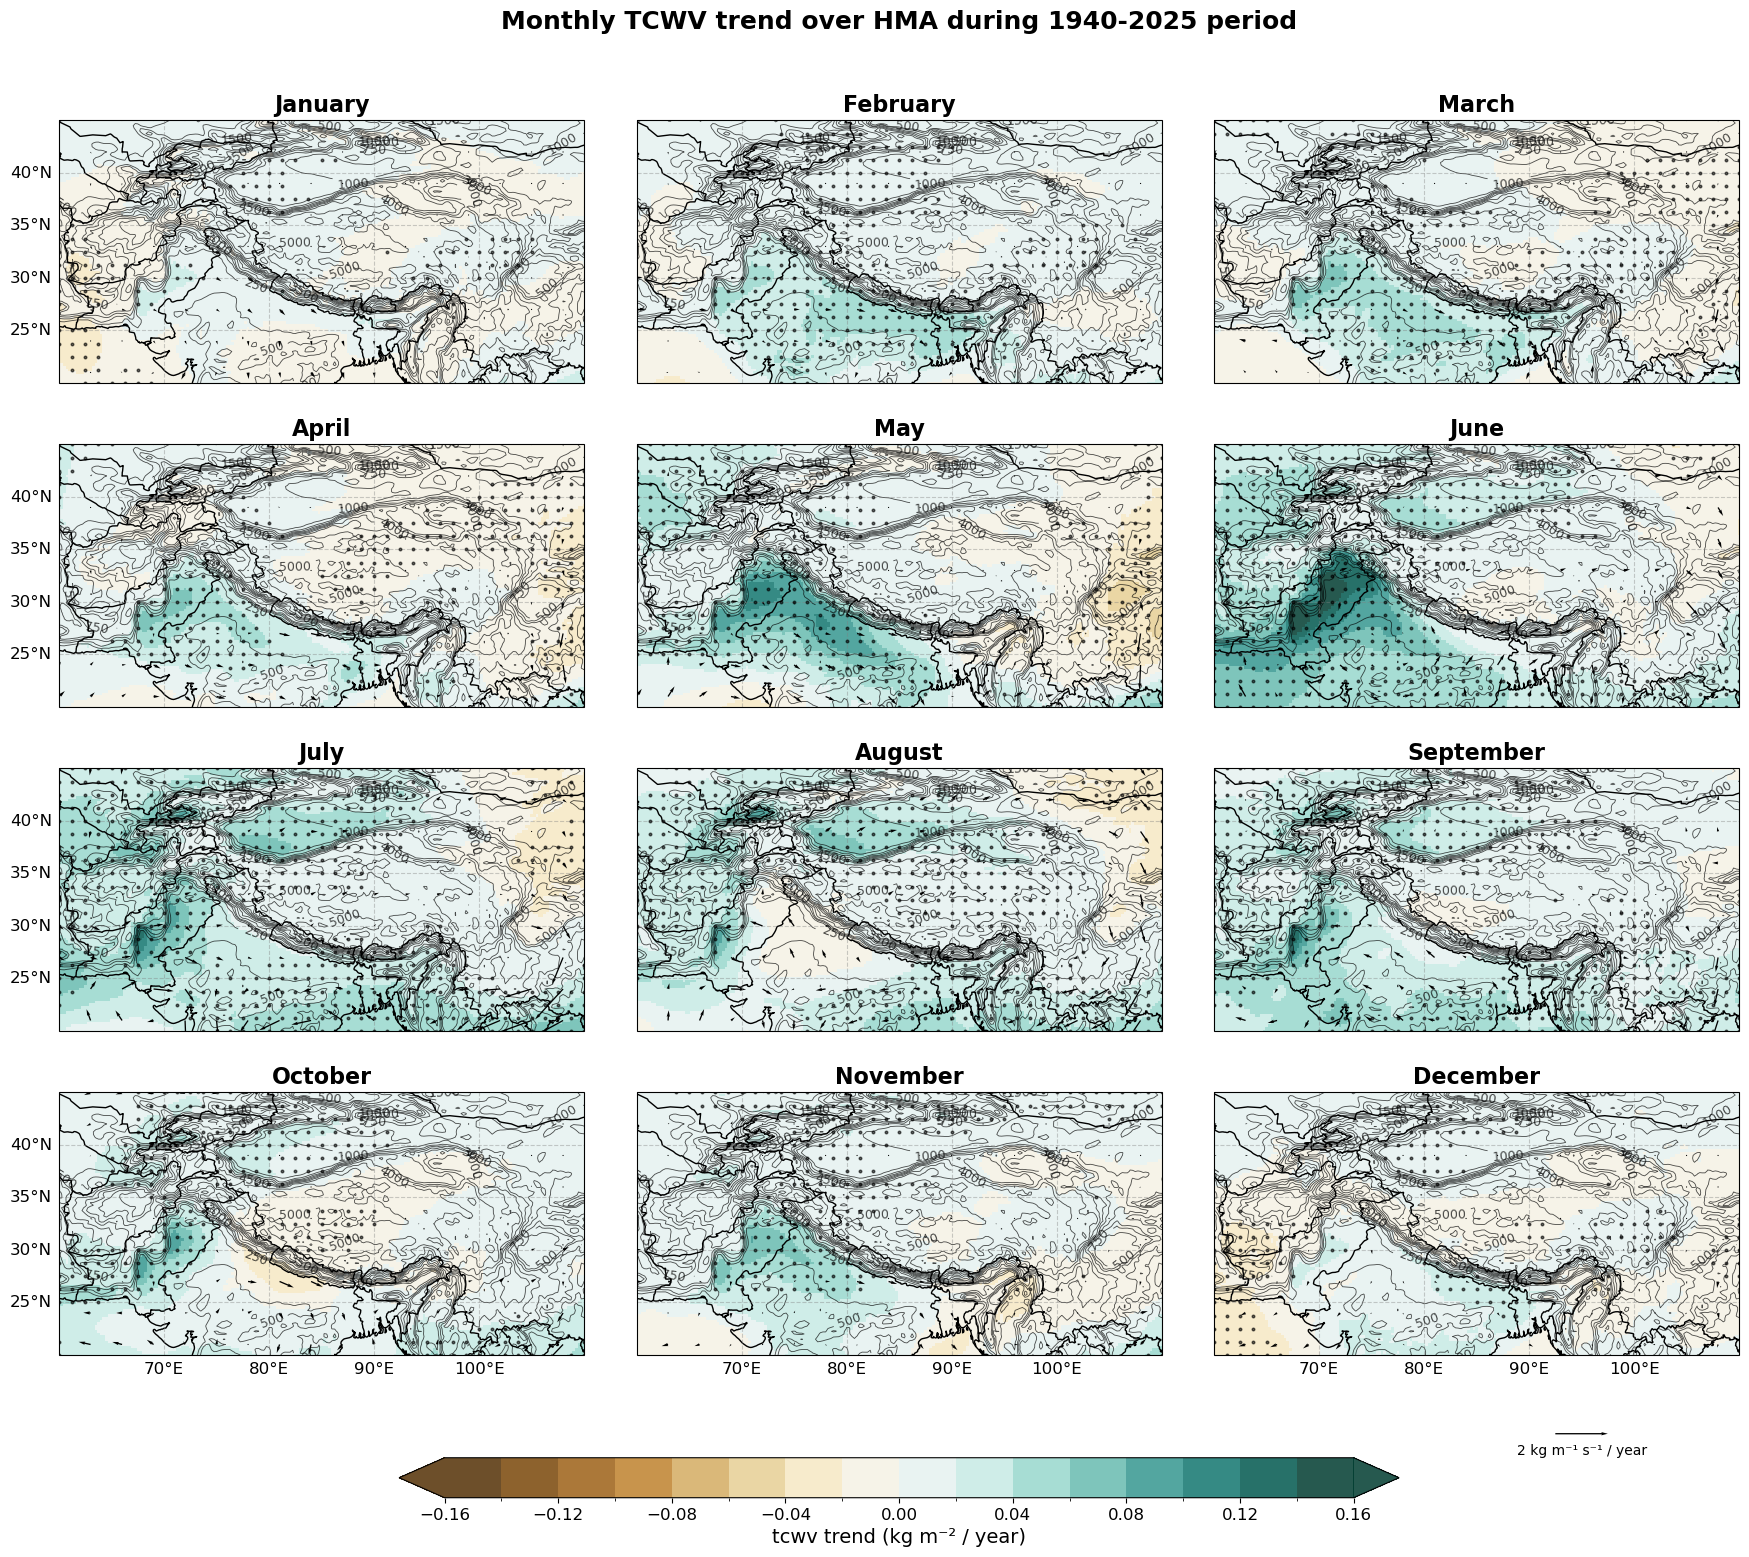

In [22]:
seasons_str = ["January", "February", "March", "April",
                "May", "June", "July", "August",
                "September", "October", "November", "December"]
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']

step = 0.02
vmax = 0.16
#vmax = round(max(float(np.abs(ds.max().values)) for ds in trend_dict.values()), 2)
print(vmax)
levels = np.arange(-vmax, vmax + step, step)
cmap = plt.get_cmap("BrBG", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(4, 3, figsize=(20, 16), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = trend_dict[season]

    im = ax.pcolormesh(data_season['longitude'],data_season['latitude'],data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,
                       shading="auto", alpha=0.85)

    #Map limitations
    ax.set_extent([
        float(tcwv_mean.longitude.min()),
        float(tcwv_mean.longitude.max()),
        float(tcwv_mean.latitude.min()),
        float(tcwv_mean.latitude.max())
    ], crs=ccrs.PlateCarree())
    
    sig = p_dict[season] < 0.05   
    step = 5
    lon_sig, lat_sig = data_season['longitude'].values, data_season['latitude'].values
    lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
    ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
           color='black', s=3.5, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha = 0.6)

    step = 12
    u_plot = u_trend_dict[season][::step, ::step]
    v_plot = v_trend_dict[season][::step, ::step]
    q = ax.quiver(u_plot['longitude'], u_plot['latitude'],u_plot, v_plot,transform=ccrs.PlateCarree(),
                  scale=20,width=0.0025,headwidth=2.5,rasterized=True)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="k",linewidths=0.6,alpha=0.7,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(seasons_str[i], fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 3 == 0)
    gl.bottom_labels = (i >= 9) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tcwv trend (kg m⁻² / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.quiverkey(q,0.70, -0.3, 2,"2 kg m⁻¹ s⁻¹ / year",labelpos='S',coordinates='axes')


fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.12, wspace=0.1, hspace=0)
plt.suptitle(f"Monthly TCWV trend over {dom} during {iyear}-{fyear} period", fontsize=18, weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'monthly_tcwv_trend_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()

# Seasonal Trends of IVT

In [23]:
seasons = ["DJFM", "AM", "JJAS", "ON"]
start_year = iyear
end_year = fyear
trend_dict = {}
p_dict = {}

u_trend_dict = {}
u_p_dict = {}
v_trend_dict = {}
v_p_dict = {}

#Climatology for each season
for season in seasons:
    tcwv_season,_ = seasonal_selection(tcwv_MA['tcwv'], season, start_year, end_year)
    par = trend_vect(tcwv_season.time,tcwv_season,dim='time')
    trend_season = par[0];p_season = par[3]
    trend_dict[season] = trend_season
    p_dict[season] = p_season

    uivt_season,_ = seasonal_selection(uivt_MA['viwve'], season, start_year, end_year)
    u_par = trend_vect(uivt_season.time,uivt_season,dim='time')
    u_trend_season = u_par[0];u_p_season = u_par[3]
    u_trend_dict[season] = u_trend_season
    u_p_dict[season] = u_p_season

    vivt_season,_ = seasonal_selection(vivt_MA['viwvn'], season, start_year, end_year)
    v_par = trend_vect(vivt_season.time,vivt_season,dim='time')
    v_trend_season = v_par[0];v_p_season = v_par[3]
    v_trend_dict[season] = v_trend_season
    v_p_dict[season] = v_p_season

(D- 1940  JF- 1941  to D- 2025 JF- 2026
(D- 1940  JF- 1941  to D- 2025 JF- 2026
(D- 1940  JF- 1941  to D- 2025 JF- 2026


0.16


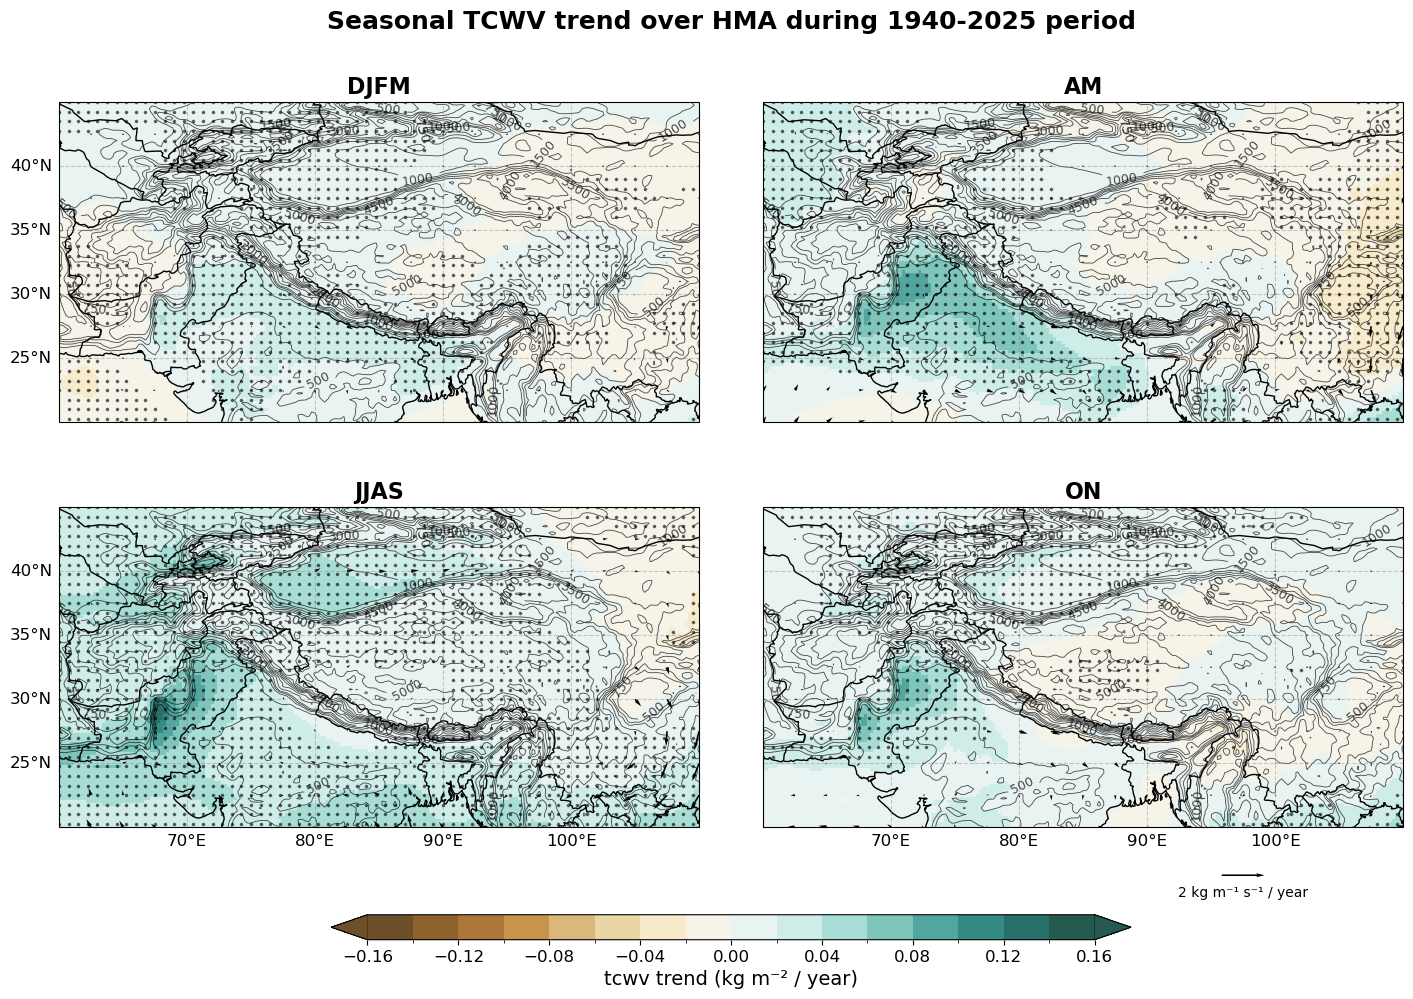

In [24]:
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/gmted/gmted_on_era5_MA.nc')['elevation']
step = 0.02
vmax = 0.16
#vmax = round(max(float(np.abs(ds.max().values)) for ds in trend_dict.values()), 2)
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG", len(levels)-1)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_season = trend_dict[season]

    im = ax.pcolormesh(data_season['longitude'],data_season['latitude'],data_season,transform=ccrs.PlateCarree(),cmap=cmap,norm=norm,
                       shading="auto", alpha=0.85)

    #Map limitations
    ax.set_extent([
        float(tcwv_mean.longitude.min()),
        float(tcwv_mean.longitude.max()),
        float(tcwv_mean.latitude.min()),
        float(tcwv_mean.latitude.max())
    ], crs=ccrs.PlateCarree())
    
    sig = p_dict[season] < 0.05   
    step = 3
    lon_sig, lat_sig = data_season['longitude'].values, data_season['latitude'].values
    lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
    ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
           color='black', s=2.5, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.5)

    step = 10
    u_plot = u_trend_dict[season][::step, ::step]
    v_plot = v_trend_dict[season][::step, ::step]
    q = ax.quiver(u_plot['longitude'], u_plot['latitude'],u_plot, v_plot,transform=ccrs.PlateCarree(),
                  scale=30,width=0.0025,headwidth=2.5,rasterized=True)
    
    ax.add_feature(cfeature.COASTLINE, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle="-")

    SH = ax.contour(elev.longitude,elev.latitude,elev,levels=[250,500,750,1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,6500,7000],
                colors="k",linewidths=0.6,alpha=0.7,transform=ccrs.PlateCarree())
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tcwv trend (kg m⁻² / year)", fontsize=14)
cbar.ax.tick_params(labelsize=12)
ax.quiverkey(q,0.75, -0.15, 2,"2 kg m⁻¹ s⁻¹ / year",labelpos='S',coordinates='axes')


fig.subplots_adjust(left=0.08, right=0.92, top=0.93, bottom=0.12, wspace=0.1, hspace=0)
plt.suptitle(f"Seasonal TCWV trend over {dom} during {iyear}-{fyear} period", fontsize=18, weight="bold")

#Save
#plotsDir="/home/bricej/figures/climbas_tcwv_era5/"
#plotname=f'monthly_tcwv_trend_{dom}_{iyear}-{fyear}'
#plt.savefig(f"{plotsDir}{plotname}.png", bbox_inches="tight")
#print(f"Saved: {plotsDir}{plotname}.png")

plt.show()